# **Model:** Logistic Regression (Baseline)

## 1. Install & Import Libraries

Installs and imports the libraries required for data processing, Logistic Regression modelling, class imbalance handling, evaluation, visualisation and cross-validation. Scikit-learn provides the preprocessing, Logistic Regression and evaluation tools while imbalanced-learn provides SMOTE and the Pipeline used during cross-validation.

In [16]:
# Install imbalanced-learn for SMOTE
!pip install imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay, average_precision_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')
print('Libraries loaded')

Libraries loaded


## 2. Load Dataset

Loads the dataset from Base.csv into a Pandas DataFrame. The shape of the dataset is checked to confirm that one million observations and 32 variables have been loaded successfully. The first few rows are also displayed to inspect the structure and values before preprocessing begins.

In [17]:
df = pd.read_csv('Base.csv') 
print(f'Shape: {df.shape}')
df.head()

Shape: (1000000, 32)


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,...,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,...,0,200.0,0,INTERNET,3.743048,other,0,1,0,0


## 3. Preprocessing

The following preprocessing steps prepare the dataset for Logistic Regression. These include handling invalid negative values, encoding categorical variables, separating the predictors from the target variable, creating the train-test split, scaling the features and addressing class imbalance using SMOTE.

### 3.1 Handle Negative Values

Examines and corrects negative values in session_length_in_minutes and device_distinct_emails_8w. These negative values represent missing or unknown information rather than meaningful negative measurements.

The values are clipped to zero to retain the observations while preventing invalid negative values from being passed to the model. The minimum values are checked before and after cleaning to confirm that the transformation has been applied correctly.

In [ ]:
print('Before cleaning:')
print(f'  session_length_in_minutes  : min = {df["session_length_in_minutes"].min()}')
print(f'  device_distinct_emails_8w  : min = {df["device_distinct_emails_8w"].min()}')


df['session_length_in_minutes'] = df['session_length_in_minutes'].clip(lower=0)
df['device_distinct_emails_8w'] = df['device_distinct_emails_8w'].clip(lower=0)

print('\nAfter cleaning:')
print(f'  session_length_in_minutes  : min = {df["session_length_in_minutes"].min()}')
print(f'  device_distinct_emails_8w  : min = {df["device_distinct_emails_8w"].min()}')
print('\nNegative values handled')

Before cleaning:
  session_length_in_minutes  : min = -1.0
  device_distinct_emails_8w  : min = -1

After cleaning:
  session_length_in_minutes  : min = 0.0
  device_distinct_emails_8w  : min = 0

Negative values handled


`session_length_in_minutes` and `device_distinct_emails_8w` contain negative values in the raw dataset. According to the dataset documentation, negative values in these fields represent **missing or unknown data** rather than true negative measurements.

Replace negative values with 0 using `.clip(lower=0)`. This is a conservative approach that avoids data loss while preventing negative values from distorting the model. An alternative would be imputation with the median, but clipping to 0 is more interpretable in this context (unknown session length treated as zero).


### 3.2 Encode Categorical Columns

Converts the categorical variables payment_type, employment_status, housing_status, source, and device_os into numerical representations using Label Encoding.

Machine learning algorithms require numerical inputs so this transformation allows these categorical features to be included in Logistic Regression together with the existing numerical variables.

In [19]:
cat_cols = ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
    print(f'  {col} encoded')

print('\nAll categorical columns encoded')

  payment_type encoded
  employment_status encoded
  housing_status encoded
  source encoded
  device_os encoded

All categorical columns encoded


### 3.3 Split Features and Target

Separates the target variable, fraud_bool, from the predictor variables. The resulting feature matrix contains 31 predictors while the target contains the binary fraud labels.

The class distribution is also examined. Approximately 98.9% of the observations are legitimate and only 1.1% are fraudulent, confirming that the dataset is highly imbalanced and that class-imbalance handling is necessary.

In [20]:
X = df.drop('fraud_bool', axis=1)
y = df['fraud_bool']

print(f'Features (X): {X.shape}')
print(f'Target  (y): {y.shape}')
print(f'\nClass distribution:')
print(f'  Non-Fraud: {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)')
print(f'  Fraud:     {(y==1).sum():,} ({(y==1).mean()*100:.1f}%)')

Features (X): (1000000, 31)
Target  (y): (1000000,)

Class distribution:
  Non-Fraud: 988,971 (98.9%)
  Fraud:     11,029 (1.1%)


### 3.4 Train/Test Split

Divides the dataset into 80% training data and 20% test data. stratify=y is used to preserve the original fraud proportion in both subsets resulting in an approximately 1.1% fraud rate in both the training and test sets.

A fixed random_state=42 is used for reproducibility. The test set remains separate from model training and is used only for final evaluation.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)

print(f'Training set   : {X_train.shape[0]:,} rows')
print(f'Test set       : {X_test.shape[0]:,} rows')
print(f'\nTraining fraud rate : {y_train.mean()*100:.2f}%')
print(f'Test fraud rate     : {y_test.mean()*100:.2f}%')
print('\nStratified split done')

Training set   : 800,000 rows
Test set       : 200,000 rows

Training fraud rate : 1.10%
Test fraud rate     : 1.10%

Stratified split done


### 3.5 Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  

print('StandardScaler applied')
print('Note: fit on train only, transform on both train and test')

StandardScaler applied
Note: fit on train only, transform on both train and test


### 3.6 Handle Class Imbalance with SMOTE

In [23]:
print('Before SMOTE:')
print(f'  Non-Fraud: {(y_train==0).sum():,}')
print(f'  Fraud:     {(y_train==1).sum():,}')

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print('\nAfter SMOTE:')
print(f'  Non-Fraud: {(y_train_sm==0).sum():,}')
print(f'  Fraud:     {(y_train_sm==1).sum():,}')
print('\nSMOTE applied  (SMOTE only on training set — NOT on test)')

Before SMOTE:
  Non-Fraud: 791,177
  Fraud:     8,823

After SMOTE:
  Non-Fraud: 791,177
  Fraud:     791,177

SMOTE applied  (SMOTE only on training set — NOT on test)


## 4. Train Logistic Regression

In [24]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

lr_model.fit(X_train_sm, y_train_sm)
print('Logistic Regression trained')

Logistic Regression trained


## 5. Evaluate Model

### 5.1 Classification Report

In [25]:
y_pred      = lr_model.predict(X_test_scaled)
y_pred_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

print('CLASSIFICATION REPORT')
print('=' * 55)
print(classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud']))
print(f'ROC-AUC Score : {roc_auc_score(y_test, y_pred_prob):.4f}')
print(f'Avg Precision : {average_precision_score(y_test, y_pred_prob):.4f}')

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.80      0.89    197794
       Fraud       0.04      0.77      0.08      2206

    accuracy                           0.80    200000
   macro avg       0.52      0.78      0.48    200000
weighted avg       0.99      0.80      0.88    200000

ROC-AUC Score : 0.8626
Avg Precision : 0.1220


### 5.2 Confusion Matrix

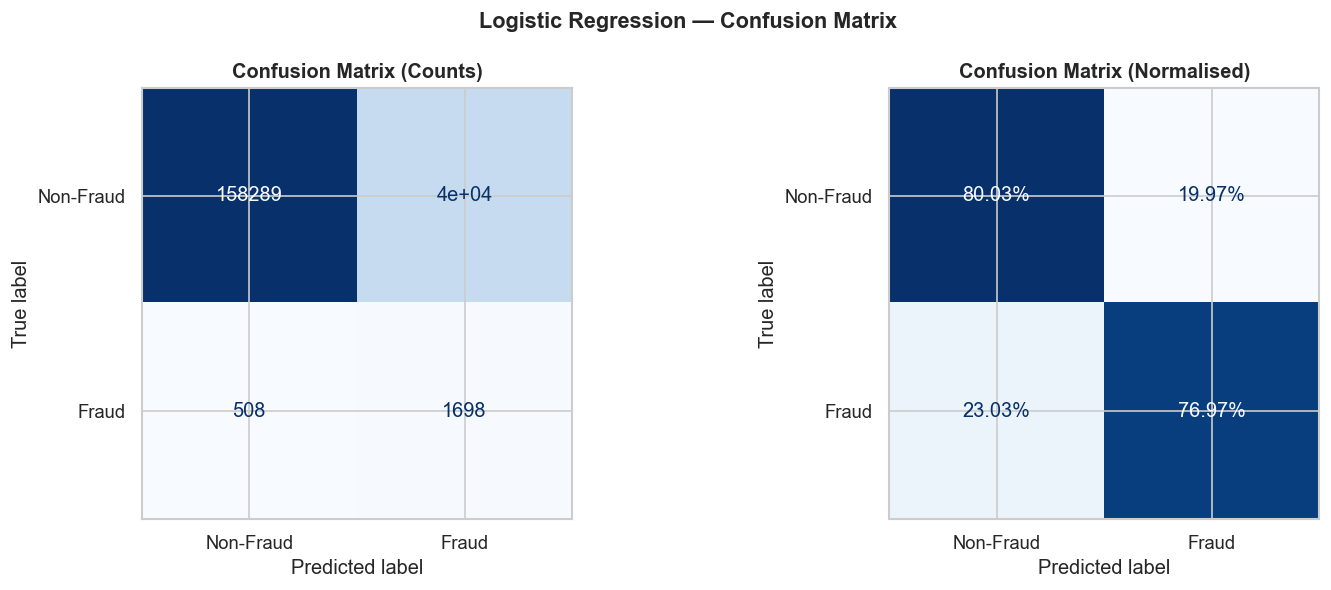

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix — counts
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Non-Fraud', 'Fraud']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')

# Confusion matrix — normalised
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=['Non-Fraud', 'Fraud']).plot(
    ax=axes[1], colorbar=False, cmap='Blues', values_format='.2%')
axes[1].set_title('Confusion Matrix (Normalised)', fontweight='bold')

plt.suptitle('Logistic Regression — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_lr.png', bbox_inches='tight')
plt.show()

### 5.3 ROC Curve & Precision-Recall Curve

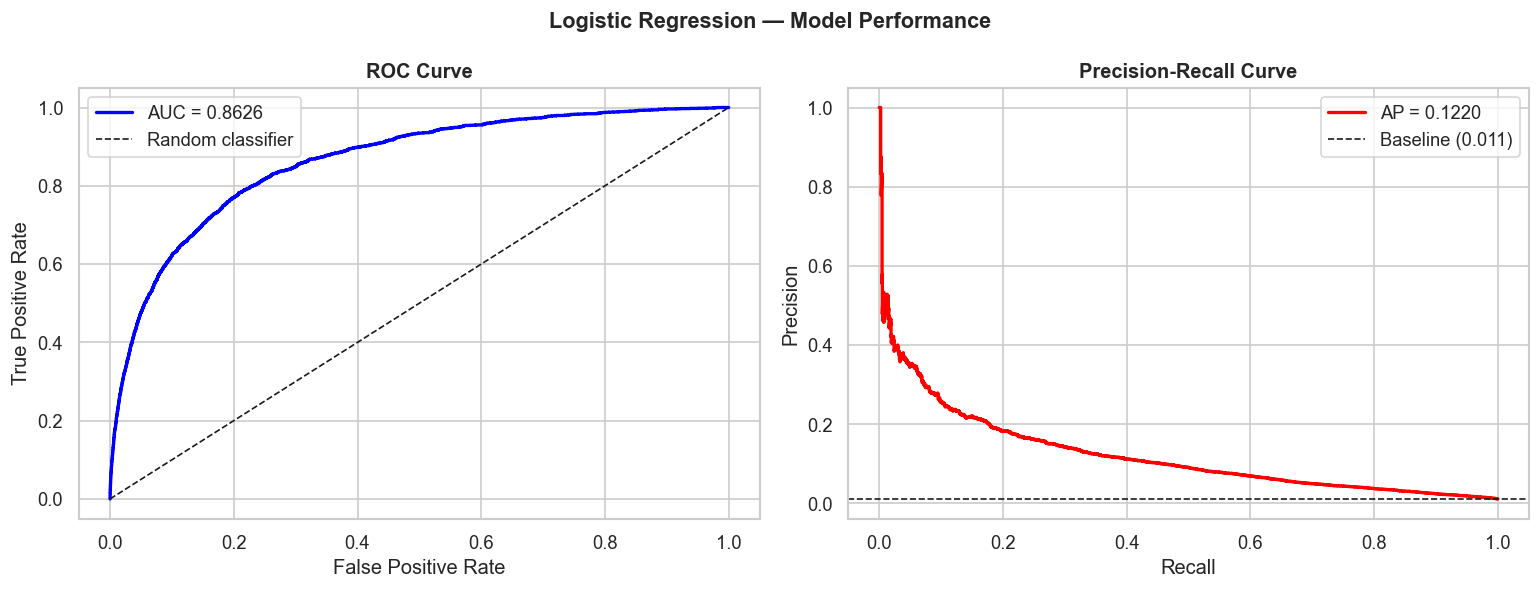

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)
axes[0].plot(fpr, tpr, color = 'blue', lw=2, label=f'AUC = {auc_score:.4f}')
axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Random classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
ap = average_precision_score(y_test, y_pred_prob)
axes[1].plot(recall, precision, color = 'red', lw=2, label=f'AP = {ap:.4f}')
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', lw=1, label=f'Baseline ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend()

plt.suptitle('Logistic Regression — Model Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_pr_curve_lr.png', bbox_inches='tight')
plt.show()

### 5.4 Cross-Validation

In [28]:
print('Running 5-fold Stratified Cross-Validation...')
print('(using 100,000 sample for speed)')

sample_idx = np.random.choice(len(X_train_scaled), size=100000, replace=False)
X_cv = X_train_scaled[sample_idx]
y_cv = y_train.iloc[sample_idx] if hasattr(y_train, 'iloc') else y_train[sample_idx]

cv_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_pipeline, X_cv, y_cv, cv=cv, scoring='roc_auc')

print(f'\nCV ROC-AUC Scores : {cv_scores.round(4)}')
print(f'Mean              : {cv_scores.mean():.4f}')
print(f'Std               : {cv_scores.std():.4f}')

Running 5-fold Stratified Cross-Validation...
(using 100,000 sample for speed)

CV ROC-AUC Scores : [0.8582 0.8622 0.8586 0.8597 0.8503]
Mean              : 0.8578
Std               : 0.0040


### 5.5 Feature Importance (Coefficients)

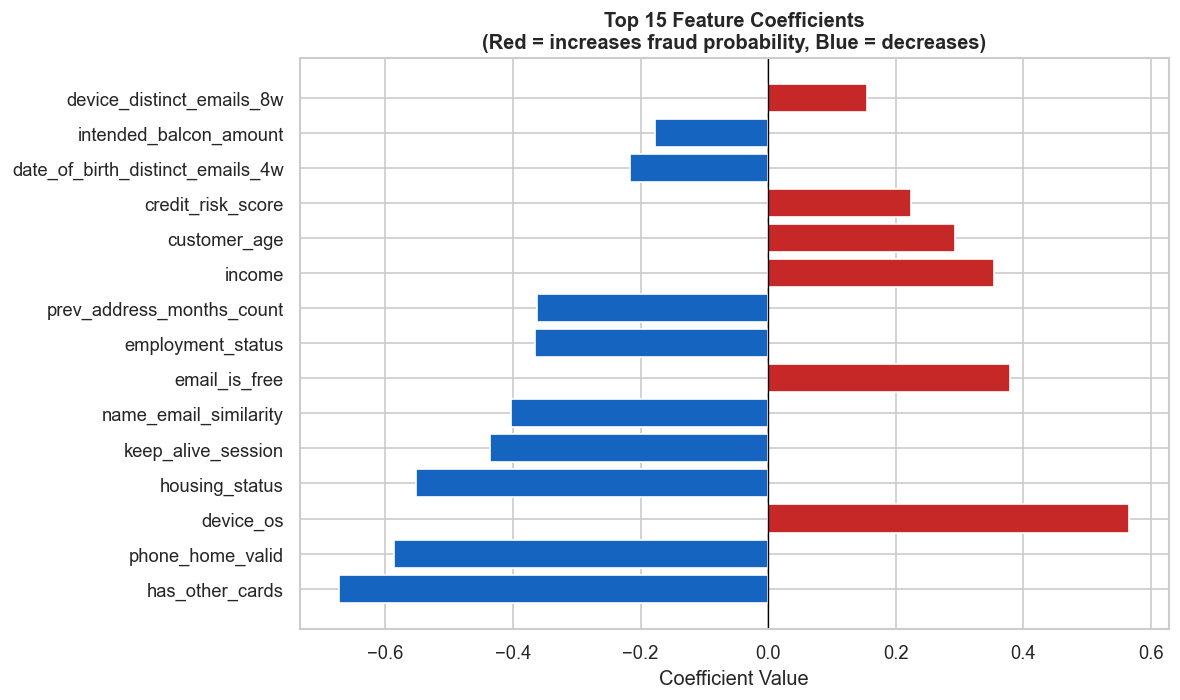

                         Feature  Coefficient
                 has_other_cards    -0.672425
                phone_home_valid    -0.586307
                       device_os     0.565800
                  housing_status    -0.552550
              keep_alive_session    -0.435420
           name_email_similarity    -0.402283
                   email_is_free     0.378255
               employment_status    -0.365952
       prev_address_months_count    -0.362280
                          income     0.353905
                    customer_age     0.292247
               credit_risk_score     0.223605
date_of_birth_distinct_emails_4w    -0.216238
          intended_balcon_amount    -0.176928
       device_distinct_emails_8w     0.154260


In [29]:
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors = ['#C62828' if c > 0 else '#1565C0' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Top 15 Feature Coefficients\n(Red = increases fraud probability, Blue = decreases)', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_lr.png', bbox_inches='tight')
plt.show()
print(coef_df.to_string(index=False))

## 6. Results Summary

In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score

print('=' * 55)
print('  LOGISTIC REGRESSION — RESULTS SUMMARY')
print('=' * 55)
print(f'  Accuracy          : {(y_pred==y_test).mean()*100:.2f}%')
print(f'  Precision (Fraud) : {precision_score(y_test, y_pred):.4f}')
print(f'  Recall    (Fraud) : {recall_score(y_test, y_pred):.4f}')
print(f'  F1-Score  (Fraud) : {f1_score(y_test, y_pred):.4f}')
print(f'  ROC-AUC           : {roc_auc_score(y_test, y_pred_prob):.4f}')
print(f'  Avg Precision     : {average_precision_score(y_test, y_pred_prob):.4f}')
print('=' * 55)

  LOGISTIC REGRESSION — RESULTS SUMMARY
  Accuracy          : 79.99%
  Precision (Fraud) : 0.0412
  Recall    (Fraud) : 0.7697
  F1-Score  (Fraud) : 0.0782
  ROC-AUC           : 0.8626
  Avg Precision     : 0.1220


In [31]:
print(len(df.columns), "columns total")
print([c for c in df.columns if c not in [
    'fraud_bool','income','name_email_similarity',
    'prev_address_months_count','current_address_months_count',
    'customer_age','days_since_request','intended_balcon_amount',
    'payment_type','zip_count_4w','velocity_6h','velocity_24h',
    'velocity_4w','bank_branch_count_8w','date_of_birth_distinct_emails_4w',
    'employment_status','credit_risk_score','email_is_free',
    'housing_status','phone_home_valid','phone_mobile_valid',
    'bank_months_count','has_other_cards','proposed_credit_limit',
    'foreign_request','device_os','keep_alive_session',
    'device_distinct_emails_8w','device_fraud_count','month'
]])

32 columns total
['source', 'session_length_in_minutes']
